### 0.interpreter와 Notebook Kernel이 다르면 터미널에서는 설치된 패키지가 Notebook에서 보이지 않는 문제가 생길 수 있습니다.

실행코드

In [43]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Current working directory:", Path.cwd())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python executable: c:\dev\llm-data-analysis-study\.venv\Scripts\python.exe
Python version: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
Current working directory: c:\dev\llm-data-analysis-study\titanic
pandas: 3.0.5
numpy: 2.5.3


기본 라이브러리 실행 오류 여부 확인 

현재 Python:

현재 Notebook Kernel:

현재 작업 폴더:

확인한 패키지:pandasm numpy

환경에서 추가로 확인할 점:x


# STEP 02. Titanic 데이터 확보와 로딩
02_1프로젝트 루트 찾기


In [44]:
from pathlib import Path

def get_project_root(start_path: Path | None = None) -> Path:
    """현재 위치에서 상위 폴더를 탐색해 data 폴더가 있는 프로젝트 루트를 찾는다."""
    current = (start_path or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / "data").is_dir():
            return path

    raise FileNotFoundError("data 폴더가 있는 프로젝트 루트를 찾을 수 없습니다.")

project_root = get_project_root()
data_path = project_root / "data" / "titanic" / "train.csv"

if not data_path.exists():
    raise FileNotFoundError(

        f"Titanic 데이터가 없습니다: {data_path}\n"
        "저장소 루트에서 python scripts/prepare_titanic_data.py 를 먼저 실행하세요."

    )
print("project_root:", project_root)
print("data_path:", data_path)

project_root: C:\dev\llm-data-analysis-study
data_path: C:\dev\llm-data-analysis-study\data\titanic\train.csv


프로젝트 root 및  데이터 파일 경로 가져오기 성공

02_2 데이터로딩

In [45]:
import pandas as pd

df = pd.read_csv(data_path)
print("data path:", data_path)
print("shape:", df.shape)
print("columns:", df.columns.tolist())
df.head()

data path: C:\dev\llm-data-analysis-study\data\titanic\train.csv
shape: (891, 12)
columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


df = 원본 기준 데이터
df 기본 관찰결과

STEP 03. 데이터 구조와 품질의 첫인상 확인
03_1. 크기와 앞부분 확인

In [46]:
print("shape:", df.shape)
df.head()

shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


| 구분 | 컬럼명 | 평균 / 최다값 | 데이터 범위 / 누락 | 핵심 요약 및 해석 |
| --- | --- | --- | --- | --- |
| **생존율** | `Survived` | **38.4%** | 0(사망) ~ 1(생존) | 승객 10명 중 6명은 사망 |
| **성별** | `Sex` | **남성 (64.8%)** | 남성 577명 / 여성 314명 | 남성이 여성보다 2배 가량 많음 |
| **객실 등급** | `Pclass` | **3등석** | 1등석 ~ 3등석 | 서민층인 3등석 승객 비중이 가장 높음 |
| **연령대** | `Age` | **29.7세** | 0.42세 ~ 80세 *(177건 누락)* | 20~30대 청년층이 주를 이룸 |
| **탑승 요금** | `Fare` | **$32.20** | $0 ~ $512.33 | 중앙값($14.45) 대비 초고가 티켓 존재 |
| **동반 가족** | `SibSp` / `Parch` | **0.5명 / 0.4명** | 최대 8명 / 최대 6명 | 승객 대다수(75% 이상)가 1인 탑승 |
| **탑승 항구** | `Embarked` | **S (사우스햄튼)** | S(644명), C(168명), Q(77명) | 사우스햄튼 탑승자가 72.4%로 압도적 |
| **객실 번호** | `Cabin` | **G6 (4명)** | *687건 누락 (77%)* | 누락이 심하여 변수 제거/재가공 필요 |

03_2 dtype과 기본 구조 확인

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


- 어떤 컬럼이 숫자형인가?
* Passenger Survived Pclass Sibsp Parch
- 어떤 컬럼이 문자열인가?
* Name,Sex,Ticket,Cabin,Embarked
- 숫자로 저장되어 있지만 실제 의미는 범주형인 컬럼이 있는가?
- Survived  Pclass
* 결측치가 보이는가?Cabin,Age,Embarked

02_3. 결측치 요약

In [48]:

missing_count = df.isna().sum()
missing_rate = (df.isna().mean() * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_rate_pct": missing_rate,
}).sort_values("missing_count", ascending=False)
missing_summary


,missing_count,missing_rate_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


02_04 중복과 기초 통계

In [49]:
print("duplicate rows:", df.duplicated().sum())
df.describe(include="all")

duplicate rows: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [50]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

★ 개인 판단 지점 1

 

학생이 추가로 확인하고 싶은 데이터 품질 항목을 하나 선택합니다.

 
- PassengerId 중복 여부

- Age 범위

- Fare 이상치

- 각 범주형 컬럼의 unique 개수

- Sex / Embarked / Pclass의 값 분포



STEP 04. 분석 문제와 Target 정의
04_1 Target 확인

In [51]:
print("Survived missing:", df["Survived"].isna().sum())
print("Survived unique:", sorted(df["Survived"].dropna().unique()))
#등급별 생존자
print("\nClass count")
print(df["Survived"].value_counts().sort_index())
#등급별 비율
print("\nClass ratio")
print(df["Survived"].value_counts(normalize=True).sort_index())

Survived missing: 0
Survived unique: [np.int64(0), np.int64(1)]

Class count
Survived
0    549
1    342
Name: count, dtype: int64

Class ratio
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


Survived가 0과 1 두 범주이므로 이번 문제는 기본적으로 이진 분류(Binary Classification) 문제입니다.

04_2 Feature와 Target


- Feature = 예측에 사용할 입력 정보
- Target  = 맞히고 싶은 정답

예를 들어 Sex, Pclass, Age, Fare 등은 Feature 후보가 될 수 있고 Survived는 Target입니다.

STEP 05. 결측치 처리

In [52]:
df_work = df.copy()    
#df      = 원본 기준 데이터

#df_work = STEP 05~10 탐색 / EDA 작업본


# 결측치 다시 확인

In [53]:
missing_summary = pd.DataFrame({
    "count": df_work.isna().sum(),
    "rate_pct": (df_work.isna().mean() * 100).round(2),
}).sort_values("count", ascending=False)

missing_summary

,count,rate_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


In [54]:

age_median = df_work["Age"].median()
embarked_mode = df_work["Embarked"].mode().iloc[0]
df_work["Age"] = df_work["Age"].fillna(age_median)
df_work["Embarked"] = df_work["Embarked"].fillna(embarked_mode)


In [55]:
df_work[["Age", "Embarked", "Cabin"]].isna().sum()


Age           0
Embarked      0
Cabin       687
dtype: int64

# STEP 06. 불필요한 컬럼 검토

- KEEP    = 그대로 사용할 후보
- EXCLUDE = 모델 입력에서는 제외할 후보
- DERIVE  = 새로운 Feature를 만들 재료
- DEFER   = 지금 결정하지 않고 보류



# STEP 07. 범주형 데이터 변환 원리 이해


In [56]:

for col in ["Sex", "Embarked", "Pclass"]:

    print(f"\n[{col}]")

    print(df_work[col].value_counts(dropna=False))



[Sex]
Sex
male      577
female    314
Name: count, dtype: int64

[Embarked]
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

[Pclass]
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [57]:
df_encoded = df_work.copy()
#df_encoded = 인코딩 원리 학습용 임시 데이터



In [58]:
#인코딩 실행
df_encoded["SexMapped"] = df_encoded["Sex"].map({
    "male": 0,
    "female": 1,
})

df_encoded[["Sex", "SexMapped"]].head()

,Sex,SexMapped
0,male,0
1,female,1
2,female,1
3,female,1
4,male,0


In [59]:
 # 판다스 메소드 pd.get_dummies()

embarked_dummies = pd.get_dummies(
    df_encoded["Embarked"],
    prefix="Embarked",
    dtype=int,
)
embarked_dummies.head()


,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1


# STEP 08. 시각화와 기본 패턴 확인

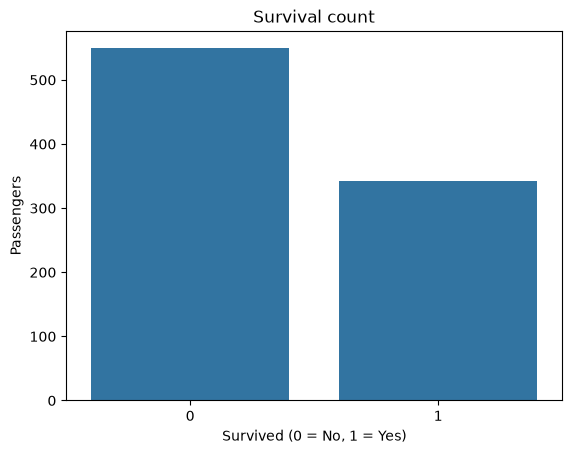

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df_work, x="Survived")
plt.title("Survival count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Passengers")
plt.show()

### 질문 2. 성별에 따라 생존율이 다른가?


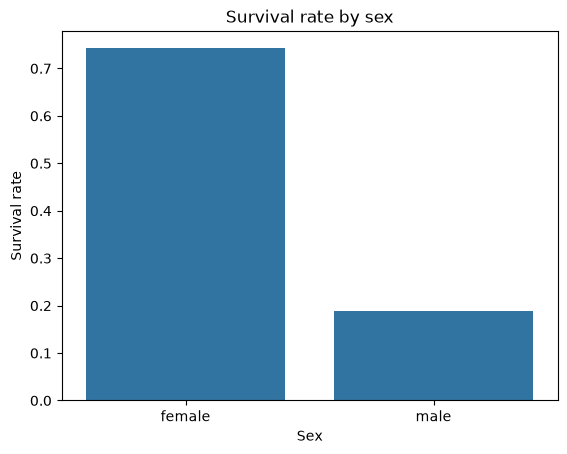

In [61]:
sex_survival = (
    df_work.groupby("Sex", as_index=False)["Survived"]
# 집계함수
    .mean()

)
sns.barplot(data=sex_survival, x="Sex", y="Survived")
plt.title("Survival rate by sex")
plt.ylabel("Survival rate")
plt.show()

###  질문 3. 객실 등급에 따라 생존율이 다른가?

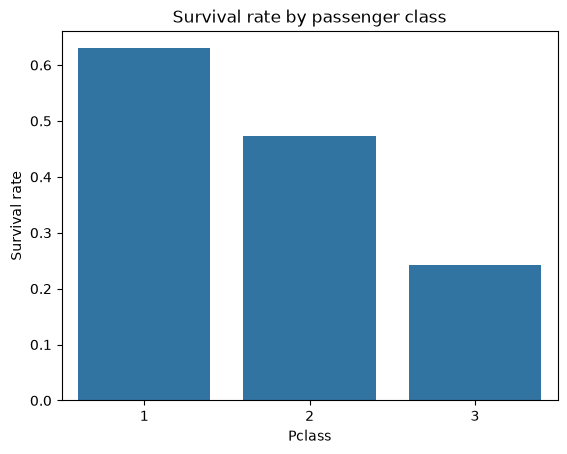

In [62]:

pclass_survival = (
    df_work.groupby("Pclass", as_index=False)["Survived"]
    .mean()
)

sns.barplot(data=pclass_survival, x="Pclass", y="Survived")
plt.title("Survival rate by passenger class")
plt.ylabel("Survival rate")
plt.show()

###  질문 4. 나이와 생존 사이에 어떤 패턴이 보이는가?

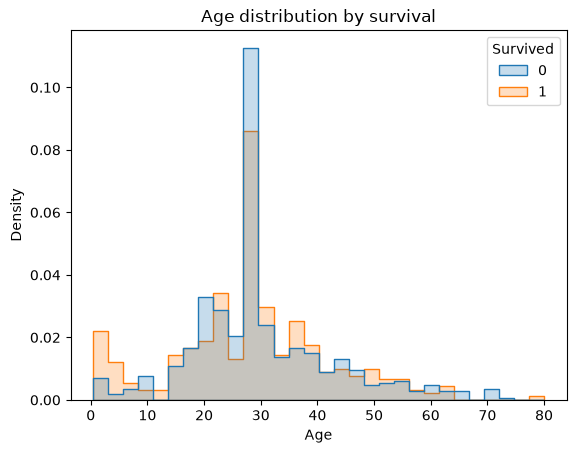

In [63]:
sns.histplot(
    data=df_work,
    x="Age",
    hue="Survived",
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
)

plt.title("Age distribution by survival")

plt.show()

### 질문 5. Fare와 생존 사이에 어떤 패턴이 보이는가?

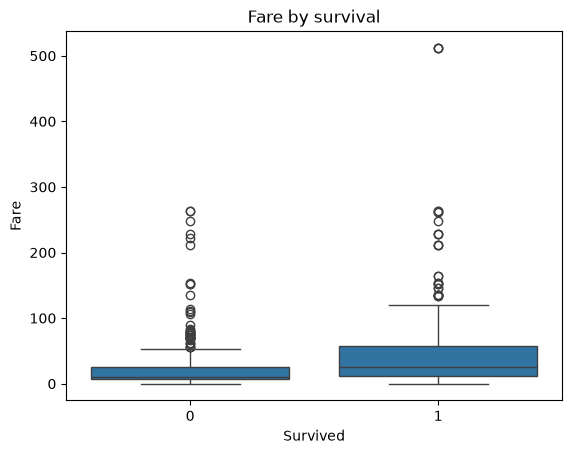

In [64]:
sns.boxplot(data=df_work, x="Survived", y="Fare")
plt.title("Fare by survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

In [65]:
display(df_work.groupby("Sex").agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))

display(df_work.groupby("Pclass").agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))

display(df_work.groupby(["Sex", "Pclass"]).agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))

,rows,survival_rate
Sex,,
female,314,0.742038
male,577,0.188908


,rows,survival_rate
Pclass,,
1,216,0.629630
2,184,0.472826
3,491,0.242363


rows  survival_rate
Sex    Pclass                     
female 1         94       0.968085
       2         76       0.921053
       3        144       0.500000
male   1        122       0.368852
       2        108       0.157407
       3        347       0.135447

In [66]:
from scipy import stats

survived = df_work.loc[df_work["Survived"] == 1, "Fare"]

not_survived = df_work.loc[df_work["Survived"] == 0, "Fare"]

t_stat, p_value = stats.ttest_ind(survived, not_survived, equal_var=False)

print("survived Fare mean:", round(survived.mean(), 2), " n =", survived.shape[0])

print("not survived Fare mean:", round(not_survived.mean(), 2), " n =", not_survived.shape[0])

print(f"t-statistic: {t_stat:.4f}")

print(f"p-value: {p_value:.3e}")

survived Fare mean: 48.4  n = 342
not survived Fare mean: 22.12  n = 549
t-statistic: 6.8391
p-value: 2.699e-11


In [67]:
feature_demo = df_work.copy()

feature_demo["FamilySize"] = feature_demo["SibSp"] + feature_demo["Parch"] + 1

feature_demo["IsAlone"] = (feature_demo["FamilySize"] == 1).astype(int)

display(feature_demo[["SibSp", "Parch", "FamilySize", "IsAlone", "Survived"]].head())

,SibSp,Parch,FamilySize,IsAlone,Survived
0,1,0,2,0,0
1,1,0,2,0,1
2,0,0,1,1,1
3,1,0,2,0,1
4,0,0,1,1,0


In [85]:
model_source = feature_demo.copy()
model_source.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
 12  FamilySize   891 non-null    int64  
 13  IsAlone      891 non-null    int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 97.6 KB


In [86]:
# 모델에 사용할 Feature
feature_columns = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
]

In [91]:
# model_source[["PassengerId", "IsAlone"]].head()
model_source[feature_columns].head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,2,0
1,1,female,38.0,1,0,71.2833,C,2,0
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,2,0
4,3,male,35.0,0,0,8.0500,S,1,1


In [92]:
X = model_source[feature_columns].copy()
y = model_source["Survived"].astype(int).copy()

print("X:", X.shape)
print("y:", y.shape)

display(X.head())
display(y.head())

X: (891, 9)
y: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,2,0
1,1,female,38.0,1,0,71.2833,C,2,0
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,2,0
4,3,male,35.0,0,0,8.0500,S,1,1


0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [94]:
# 그리고 마지막 셀에서 학습용/테스트용 데이터로 분리합니다.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("train:", X_train.shape, y_train.shape)
print("test :", X_test.shape, y_test.shape)

train: (712, 9) (712,)
test : (179, 9) (179,)


In [95]:
# 분리가 잘 되었는지 생존 비율도 확인합니다.

print("전체 데이터")
display(
    y.value_counts(normalize=True)
     .sort_index()
     .rename("ratio")
     .to_frame()
)

print("학습 데이터")
display(
    y_train.value_counts(normalize=True)
           .sort_index()
           .rename("train_ratio")
           .to_frame()
)

print("테스트 데이터")
display(
    y_test.value_counts(normalize=True)
          .sort_index()
          .rename("test_ratio")
          .to_frame()
)

전체 데이터


,ratio
Survived,
0,0.616162
1,0.383838


학습 데이터


,train_ratio
Survived,
0,0.616573
1,0.383427


테스트 데이터


,test_ratio
Survived,
0,0.614525
1,0.385475
